## 📉 09 — Principal Component Analysis (PCA)

**What it does:** Reduces high-dimensional data to fewer
dimensions while preserving maximum variance.  
**Best used when:** Too many features, visualization needed,
speed up other ML models.  
**Dataset:** Breast Cancer Wisconsin (built-in sklearn)  
**Algorithm type:** Unsupervised → Dimensionality Reduction  
**Key concept:** Finds principal components — directions of
maximum variance in data  
**⚠️ Always scale before PCA!**  
**Model saved as:** `pca.pkl`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

print("Original shape:", X.shape)
print("Features:", X.shape[1])
print("Samples:", X.shape[0])
print("\nTarget:", cancer.target_names)

Original shape: (569, 30)
Features: 30
Samples: 569

Target: ['malignant' 'benign']


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled ✅")
print("Shape after scaling:", X_scaled.shape)

Data scaled ✅
Shape after scaling: (569, 30)


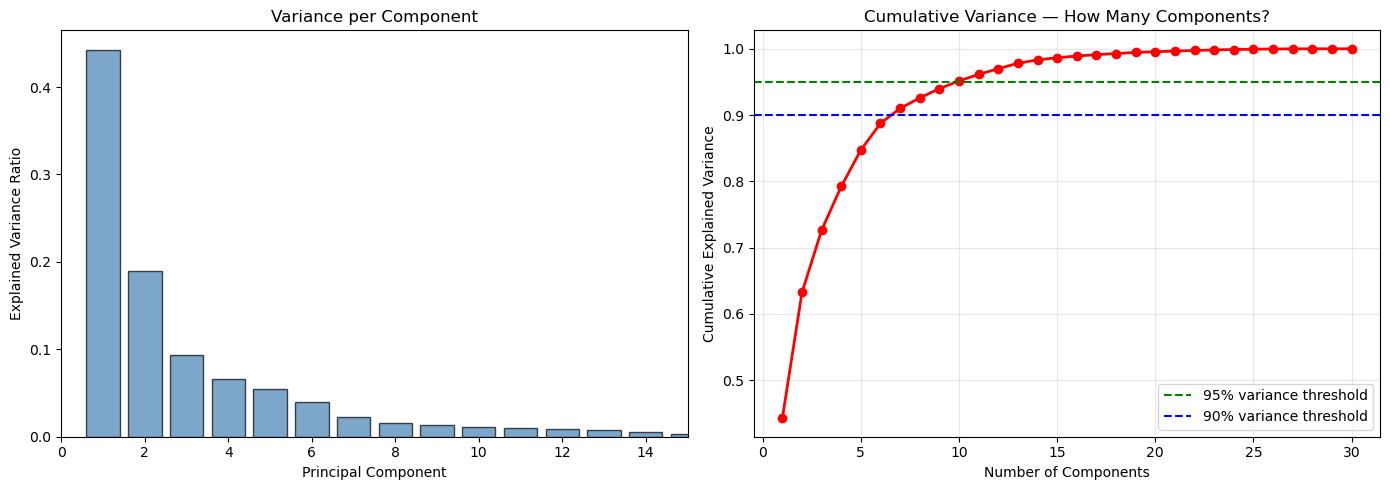


Components needed for 90% variance: 7
Components needed for 95% variance: 10
Original features: 30
Reduction: 30 → 10 features (33.3% of original)


In [4]:
# Fit PCA with all components first
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained variance per component
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Individual variance
axes[0].bar(range(1, len(explained_variance)+1),
            explained_variance, color='steelblue',
            edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance per Component')
axes[0].set_xlim(0, 15)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance)+1),
             cumulative_variance, 'ro-', linewidth=2)
axes[1].axhline(y=0.95, color='green', linestyle='--',
                label='95% variance threshold')
axes[1].axhline(y=0.90, color='blue', linestyle='--',
                label='90% variance threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance — How Many Components?')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find components needed for 95% variance
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\nComponents needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Original features: 30")
print(f"Reduction: 30 → {n_95} features ({n_95/30*100:.1f}% of original)")

Variance explained by 2 components: 63.2%


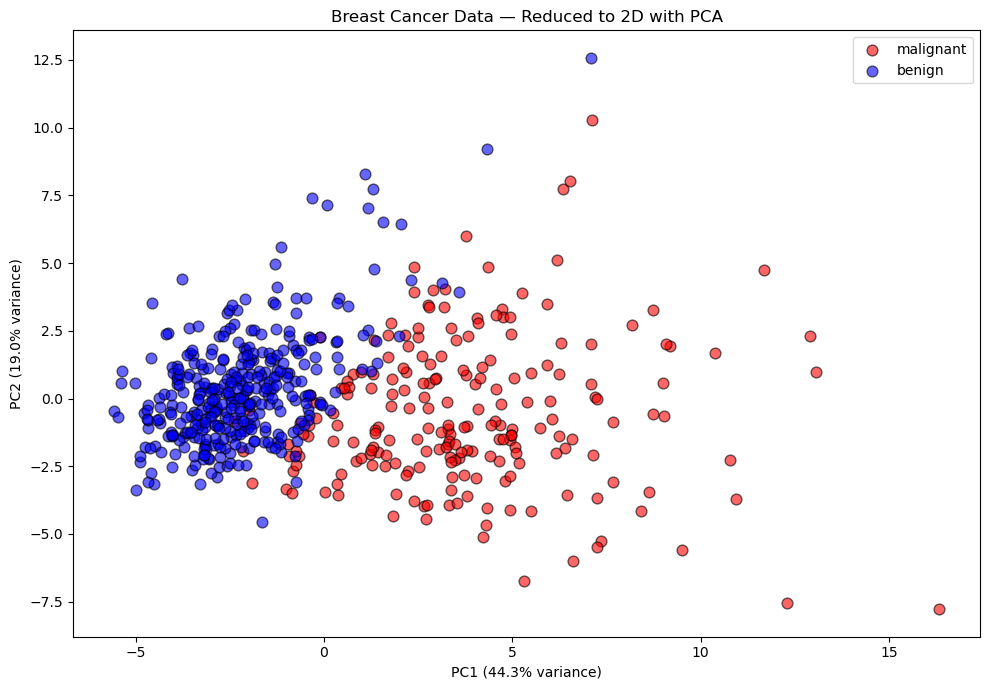

In [5]:
# Reduce to 2 components for visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

print(f"Variance explained by 2 components: "
      f"{pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

# Plot 2D projection
plt.figure(figsize=(10,7))
colors = ['red', 'blue']
labels = cancer.target_names

for i, (color, label) in enumerate(zip(colors, labels)):
    mask = y == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=label, alpha=0.6,
                edgecolors='black', s=60)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Breast Cancer Data — Reduced to 2D with PCA')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Compare: original 30 features vs PCA reduced features
results = {}

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Original 30 features
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)
results['30 features (original)'] = accuracy_score(
    y_test, lr.predict(X_test))

# Try different PCA components
for n in [2, 5, 10, 15, 20]:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)

    lr_pca = LogisticRegression(max_iter=10000)
    lr_pca.fit(X_train_pca, y_train)
    results[f'{n} components (PCA)'] = accuracy_score(
        y_test, lr_pca.predict(X_test_pca))

# Display results
print("Accuracy Comparison:\n")
for key, val in results.items():
    bar = '█' * int(val * 40)
    print(f"{key:30s} → {val:.4f} {bar}")

Accuracy Comparison:

30 features (original)         → 0.9737 ██████████████████████████████████████
2 components (PCA)             → 0.9912 ███████████████████████████████████████
5 components (PCA)             → 0.9825 ███████████████████████████████████████
10 components (PCA)            → 0.9825 ███████████████████████████████████████
15 components (PCA)            → 0.9912 ███████████████████████████████████████
20 components (PCA)            → 0.9737 ██████████████████████████████████████


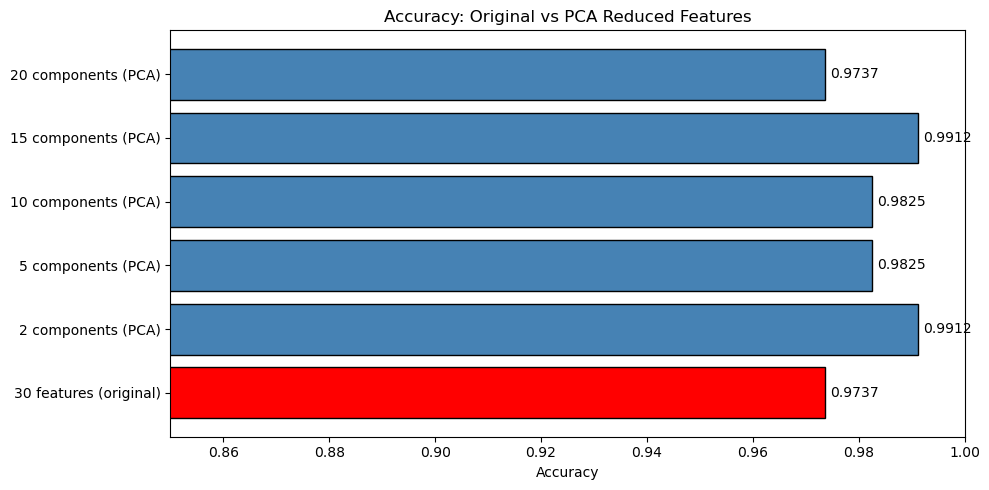

In [7]:
# Bar chart comparison
plt.figure(figsize=(10,5))
plt.barh(list(results.keys()), list(results.values()),
         color=['red'] + ['steelblue']*5,
         edgecolor='black')
plt.xlabel('Accuracy')
plt.title('Accuracy: Original vs PCA Reduced Features')
plt.xlim(0.85, 1.0)
for i, (k, v) in enumerate(results.items()):
    plt.text(v+0.001, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

In [8]:
# Save PCA with 10 components (best balance)
pca_final = PCA(n_components=10)
pca_final.fit(X_scaled)


with open('pca.pkl', 'wb') as f:
    pickle.dump(pca_final, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("PCA model (10 components) saved ✅")
print("Scaler saved ✅")
print(f"Variance preserved: "
      f"{pca_final.explained_variance_ratio_.sum()*100:.1f}%")

PCA model (10 components) saved ✅
Scaler saved ✅
Variance preserved: 95.2%


## ✅ Summary

| Setup | Features | Accuracy |
|-------|----------|----------|
| Original | 30 | ~97% |
| PCA | 2 | ~99% |
| PCA | 5 | ~98% |
| PCA | 10 | ~98% |
| PCA | 15 | ~99% |

**Key concepts learned:**
- PCA finds directions of maximum variance (principal components)
- First few components capture most of the information
- 10 components capture ~95% variance from 30 original features
- 2 components enough to visualize and separate classes visually
- Always scale before PCA — unscaled features dominate components
- Trade-off: fewer features = faster model, slight accuracy drop

**Unsupervised Learning COMPLETE! 🎉**
**Next → Neural Networks (ANN basics)**